<a href="https://colab.research.google.com/github/lawalabdurrashid123-dev/ABDURRASHID-LAWAL-23425057/blob/main/Abdurrashidlawal_23425057_UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_6431/3069349394.py:14: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_6431/3069349394.py:14: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_6431/3069349394.py:15: RuntimeWarning: divide by zero encountered in log
  img_log = c * (np.log(img + 1))
/tmp/ipykernel_6431/3069349394.py:15: RuntimeWarning: invalid value encountered in multiply
  img_log = c * (np.log(img + 1))
/tmp/ipykernel_6431/3069349394.py:16: RuntimeWarning: invalid value encountered in cast
  img_log = np.array(img_log, dtype=np.uint8)
/tmp/ipykernel_6431/3069349394.py:32: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(images[i].ravel(), 256, [0, 256])


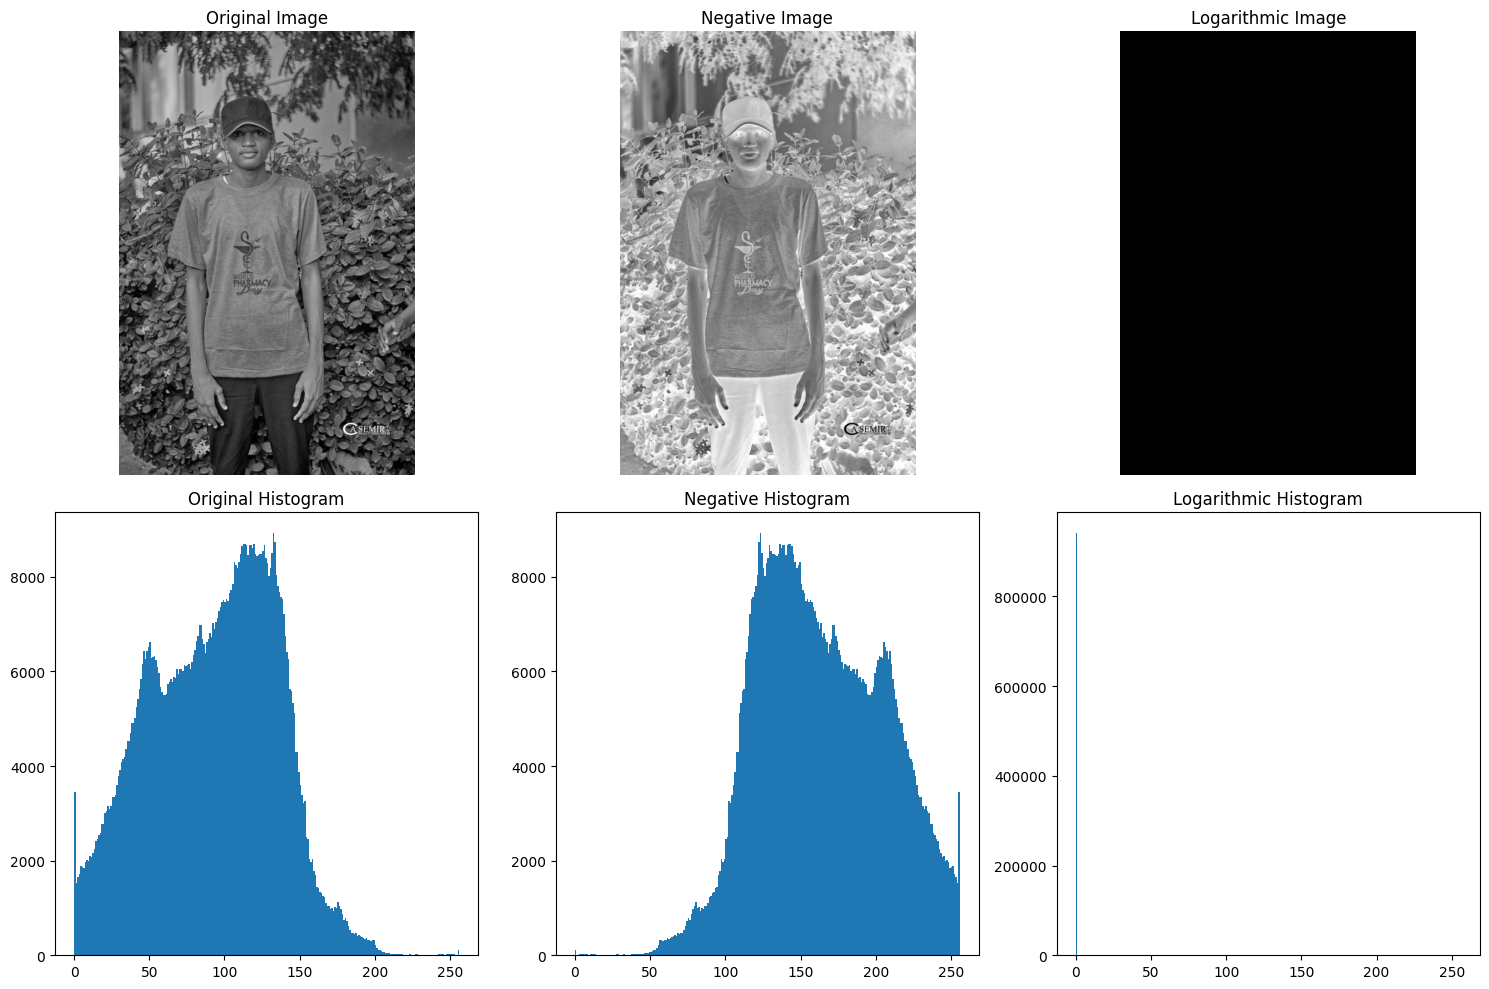

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read the grayscale image
# Upload an image named 'input.jpg' to your Colab files
img = cv2.imread('dikko.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Apply Transformations
# Negative Transformation: G = 255 - F
img_negative = 255 - img

# Logarithmic Transformation: G = c * log(1 + F)
c = 255 / np.log(1 + np.max(img))
img_log = c * (np.log(img + 1))
img_log = np.array(img_log, dtype=np.uint8)

# 3. Display Results and Histograms
titles = ['Original', 'Negative', 'Logarithmic']
images = [img, img_negative, img_log]

plt.figure(figsize=(15, 10))
for i in range(3):
    # Show Image
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f"{titles[i]} Image")
    plt.axis('off')

    # Show Histogram
    plt.subplot(2, 3, i+4)
    plt.hist(images[i].ravel(), 256, [0, 256])
    plt.title(f"{titles[i]} Histogram")

plt.tight_layout()
plt.show()

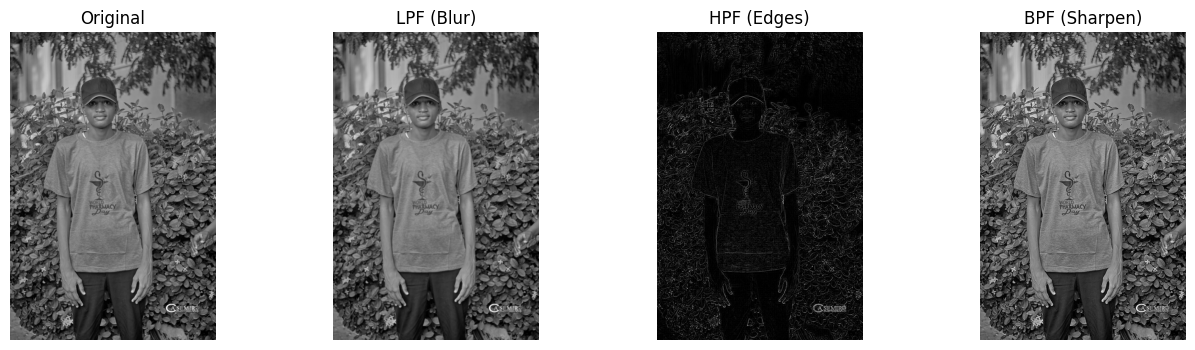

Mean Pixel Original: 91.88
Mean Pixel LPF (Blur): 91.88
Mean Pixel HPF (Edges): 13.81
Mean Pixel BPF (Sharpen): 92.32


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('dikko.jpg', cv2.IMREAD_GRAYSCALE)

# Define Kernels
kernel_lpf = np.ones((3,3), np.float32) / 9

kernel_hpf = np.array([[-1, -1, -1],
                       [-1,  8, -1],
                       [-1, -1, -1]])

kernel_bpf = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])

# Apply Convolution
res_lpf = cv2.filter2D(img, -1, kernel_lpf)
res_hpf = cv2.filter2D(img, -1, kernel_hpf)
res_bpf = cv2.filter2D(img, -1, kernel_bpf)

# Display
titles = ['Original', 'LPF (Blur)', 'HPF (Edges)', 'BPF (Sharpen)']
images = [img, res_lpf, res_hpf, res_bpf]

plt.figure(figsize=(16, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

# Print Mean Pixel Values for Analysis
for i in range(4):
    print(f"Mean Pixel {titles[i]}: {np.mean(images[i]):.2f}")